# Tebas Fairplay Report (Fantasy S2)

In [1]:
import numpy as np
import pandas as pd

trading_df = pd.read_csv('../data/trading.csv')
trading_df['date'] = pd.to_datetime(trading_df['date']).dt.date
trading_df.head(10)

,date,type,team1,team2,player,amount
0,2026-04-24,purchased,Ramonaco FC,LALIGA,A. Castrin,999999
1,2026-04-23,purchased,LamineTheTuareg,LILTEAM,Affengruber,6888888
2,2026-04-23,purchased,-papi—,LamineTheTuareg,Kiko F.,6000000
3,2026-04-23,sold,-papi—,LALIGA,Bartra,20616386
4,2026-04-23,purchased,La rataneta,cristian.ayala12,C. Soler,33091178
5,2026-04-23,purchased,Ramonaco FC,LALIGA,Edu Expésito,32555555
6,2026-04-23,purchased,Ramonaco FC,LALIGA,Thiago Fernandez,1999999
7,2026-04-23,purchased,LILTEAM,LALIGA,Olasagasti,830161
8,2026-04-23,sold,La rataneta,LALIGA,Almeida,851157
9,2026-04-23,purchased,La rataneta,LamineTheTuareg,Gavi,5000000


In [2]:
assert not(trading_df['date'].diff().dropna().dt.days > 0).any()

## Transactions

### All transactions plot

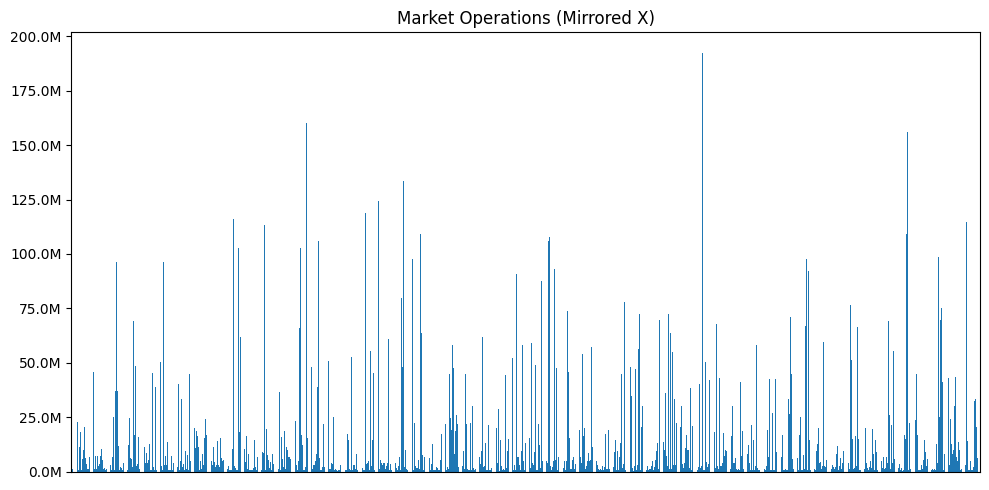

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10,5))

ax.bar(trading_df.index, trading_df['amount'])

# Invertir eix X
off = 1
ax.set_xlim(-off, len(trading_df) - off)
ax.invert_xaxis()

# Format milions
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
ax.yaxis.set_major_formatter(formatter)

plt.title('Market Operations (Mirrored X)')
plt.xticks([])

plt.tight_layout()
plt.show()

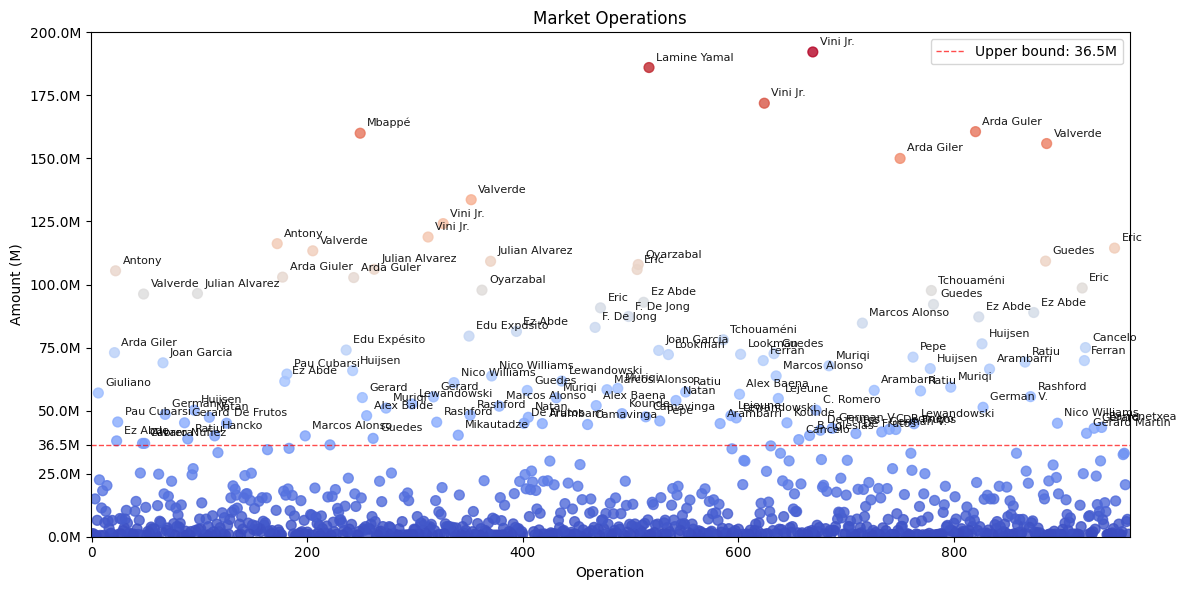

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

amounts = trading_df['amount'].values
n = len(amounts)

# Reversed positions: first record on the right, last on the left
x_plot = np.arange(n - 1, -1, -1)

# Scatter plot with color gradient: blue (cheap) -> red (expensive)
norm = plt.Normalize(vmin=amounts.min(), vmax=amounts.max())
sc = ax.scatter(x_plot, amounts, c=amounts, cmap='coolwarm', alpha=0.8, s=50, norm=norm)

# Detect outliers using IQR
Q1 = np.percentile(amounts, 25)
Q3 = np.percentile(amounts, 75)
IQR = Q3 - Q1
lower_bound = 0 #Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Draw upper bound line
ax.axhline(y=upper_bound, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'Upper bound: {upper_bound/1e6:.1f}M')
ax.legend()

outliers_mask = (amounts < lower_bound) | (amounts > upper_bound)

# Label outliers with player names
players = trading_df['player'].values
for i, (is_outlier, amount, player) in enumerate(zip(outliers_mask, amounts, players)):
    if is_outlier:
        ax.annotate(
            player,
            (x_plot[i], amount),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8,
            alpha=0.9
        )

# X axis: 0 on the left, max on the right
ax.set_xlim(-1, n)
ax.set_ylim(0, amounts.max())

# Format millions
formatter = ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
ax.yaxis.set_major_formatter(formatter)

# Add upper_bound to Y axis ticks
current_ticks = list(ax.get_yticks())
current_ticks.append(upper_bound)
ax.set_yticks(sorted(current_ticks))

plt.title('Market Operations')
plt.xlabel('Operation')
plt.ylabel('Amount (M)')

plt.tight_layout()
plt.show()

### Top transactions

In [5]:
trading_df.sort_values('amount', ascending=False).head(15)

,date,type,team1,team2,player,amount
293,2026-03-17,sold,Ramonaco FC,LALIGA,Vini Jr.,192220472
445,2026-03-02,purchased,La rataneta,LALIGA,Lamine Yamal,186047732
338,2026-03-11,purchased,Ramonaco FC,LALIGA,Vini Jr.,171892491
142,2026-04-05,sold,Ramonaco FC,LALIGA,Arda Guler,160623126
713,2026-02-03,purchased,LILTEAM,LALIGA,Mbappé,160000000
76,2026-04-12,purchased,cristian.ayala12,LALIGA,Valverde,155899209
212,2026-03-25,purchased,Ramonaco FC,LALIGA,Arda Giler,149999999
610,2026-02-13,sold,cristian.ayala12,LALIGA,Valverde,133631252
636,2026-02-11,sold,Millou912,LALIGA,Vini Jr.,124154664
650,2026-02-10,purchased,Millou912,LALIGA,Vini Jr.,118836312


### Daily stats

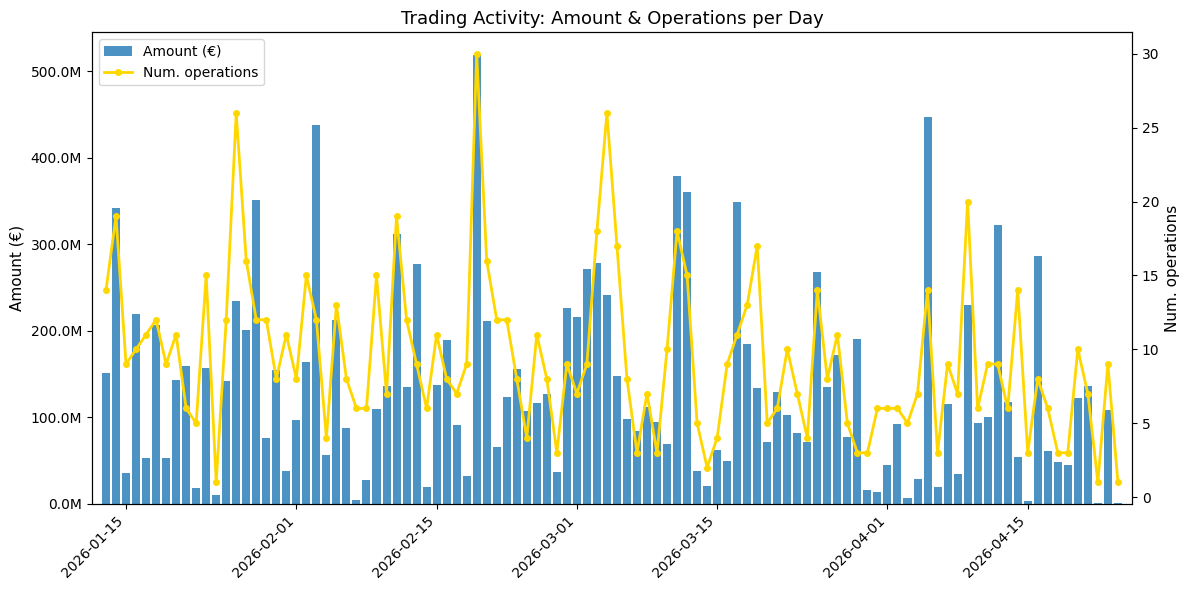

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import datetime

# --- Aggregation ---
date_groups = trading_df.groupby('date')

daily_amount = date_groups['amount'].sum()
daily_counts = trading_df['date'].value_counts()

# Full date range
full_range = pd.date_range(trading_df['date'].min(), trading_df['date'].max())

daily_amount = daily_amount.reindex(full_range, fill_value=0)
daily_counts = daily_counts.reindex(full_range, fill_value=0)

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(12,6))

# Bars (amount)
bars = ax1.bar(
    daily_amount.index,
    daily_amount,
    width=0.8,
    alpha=0.8,
    label='Amount (€)'
)

ax1.set_ylabel('Amount (€)', fontsize=11)

# Format Y axis in millions
ax1.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

# Line (counts)
ax2 = ax1.twinx()
ax2.plot(
    daily_counts.index,
    daily_counts,
    marker='o',
    color='gold',
    linewidth=2,
    markersize=4,
    label='Num. operations'
)

ax2.set_ylabel('Num. operations', fontsize=11)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='upper left'
)

# --- X axis formatting (KEY PART) ---
ax1.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=8))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

for label in ax1.get_xticklabels():
    label.set_rotation(45)
    label.set_horizontalalignment('right')

# --- Baseline ---
ax1.axhline(0, linewidth=0.6, color='black', alpha=0.6)

# --- Margins ---
ax1.margins(x=0.01)

# --- Title ---
plt.title('Trading Activity: Amount & Operations per Day', fontsize=13)

# --- Layout ---
plt.tight_layout()

plt.show()

#### Top days with more amount

In [7]:
dd = daily_amount.sort_values(ascending=False)
display(dd)
date_groups.get_group(dd.index[0].date())

2026-02-19    518762461
2026-04-05    446497655
2026-02-03    437345511
2026-03-11    378578788
2026-03-12    360767106
                ...    
2026-04-03      7065154
2026-02-07      4014859
2026-04-15      2760174
2026-04-24       999999
2026-04-22       903676
Name: amount, Length: 102, dtype: int64

,date,type,team1,team2,player,amount
539,2026-02-19,sold,LILTEAM,LALIGA,Cancelo,22203918
540,2026-02-19,sold,-papi—,LALIGA,A. Abqar,639349
541,2026-02-19,sold,-papi—,LALIGA,Chimy Avila,562359
542,2026-02-19,purchased,-papi—,JMjugon,M. Roman,1100069
543,2026-02-19,purchased,tete alejo,-papi—,Alvaro Garcia,22000000
544,2026-02-19,purchased,tete alejo,Millou912,Arambarri,44862050
545,2026-02-19,purchased,cristian.ayala12,tete alejo,Pol Lozano,1000000
546,2026-02-19,purchased,JMjugon,LALIGA,Raul Moro,9300069
547,2026-02-19,purchased,La rataneta,LALIGA,Obed Vargas,2694485
548,2026-02-19,purchased,Millou912,LALIGA,Dimitrievski,617763


#### Top days with more operations

In [8]:
dd = daily_counts.sort_values(ascending=False)
display(dd)
date_groups.get_group(dd.index[0].date())

2026-02-19    30
2026-01-26    26
2026-03-04    26
2026-04-09    20
2026-01-14    19
              ..
2026-04-15     3
2026-03-14     2
2026-01-24     1
2026-04-22     1
2026-04-24     1
Name: count, Length: 102, dtype: int64

,date,type,team1,team2,player,amount
539,2026-02-19,sold,LILTEAM,LALIGA,Cancelo,22203918
540,2026-02-19,sold,-papi—,LALIGA,A. Abqar,639349
541,2026-02-19,sold,-papi—,LALIGA,Chimy Avila,562359
542,2026-02-19,purchased,-papi—,JMjugon,M. Roman,1100069
543,2026-02-19,purchased,tete alejo,-papi—,Alvaro Garcia,22000000
544,2026-02-19,purchased,tete alejo,Millou912,Arambarri,44862050
545,2026-02-19,purchased,cristian.ayala12,tete alejo,Pol Lozano,1000000
546,2026-02-19,purchased,JMjugon,LALIGA,Raul Moro,9300069
547,2026-02-19,purchased,La rataneta,LALIGA,Obed Vargas,2694485
548,2026-02-19,purchased,Millou912,LALIGA,Dimitrievski,617763


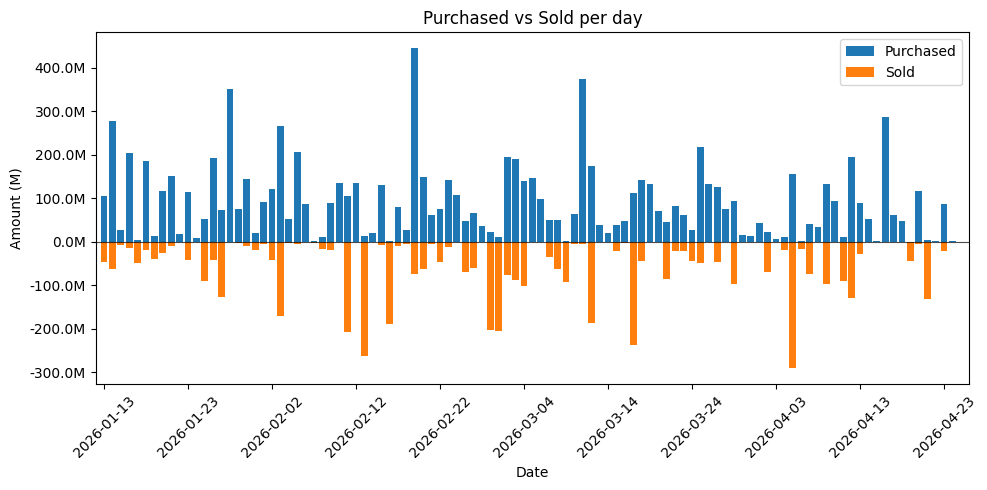

In [9]:
full_range = pd.date_range(trading_df['date'].min(), trading_df['date'].max())

daily = trading_df.groupby(['date', 'type'])['amount'].sum().unstack(fill_value=0)
daily = daily.reindex(full_range, fill_value=0)
daily = daily.reindex(columns=['purchased', 'sold'], fill_value=0)

plt.figure(figsize=(10,5))

# Purchased (positive)
x = np.arange(len(daily))
plt.bar(x, daily['purchased'], label='Purchased')
plt.bar(x, -daily['sold'], label='Sold')

plt.xticks(x, daily.index.strftime('%Y-%m-%d'), rotation=45)

plt.title('Purchased vs Sold per day')
plt.xlim(-1, len(x)+1)
plt.xlabel('Date')
plt.ylabel('Amount (M)')

step= 10
plt.gca().yaxis.set_major_formatter(formatter)
plt.xticks(x[::step], daily.index.strftime('%Y-%m-%d')[::step], rotation=45)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
daily['diff'] = daily['sold'] - daily['purchased']
daily

type,purchased,sold,diff
2026-01-13,104276294,46271593,-58004701
2026-01-14,277528645,63748033,-213780612
2026-01-15,26750001,8431704,-18318297
2026-01-16,203500840,15240395,-188260445
2026-01-17,4221331,48762351,44541020
...,...,...,...
2026-04-20,115493423,6124884,-109368539
2026-04-21,4700881,131238334,126537453
2026-04-22,903676,0,-903676
2026-04-23,86365781,21467543,-64898238


## Teams

The team with the most operations

In [11]:
trading_df['team1'].value_counts()

team1
Ramonaco FC         134
-papi—              132
cristian.ayala12     93
La rataneta          91
JMjugon              90
Millou912            83
LamineTheTuareg      78
PlatanosVerdes       66
LILTEAM              56
La Agustineta 96     51
PavelmacuFC          49
tete alejo           40
Name: count, dtype: int64

The most scouted team

In [12]:
bbt = trading_df['team2'].value_counts()
bbt

team2
LALIGA              653
La rataneta          42
Millou912            33
Ramonaco FC          31
LamineTheTuareg      30
cristian.ayala12     28
-papi—               28
tete alejo           25
LILTEAM              23
JMjugon              20
PavelmacuFC          20
PlatanosVerdes       16
La Agustineta 96     14
Name: count, dtype: int64

### The Black Beast Teams

In [13]:
bbt_group = trading_df.groupby('team2')

for team in bbt.index[1:]:
    print(f'--- {team} ---')
    display(bbt_group.get_group(team)['team1'].value_counts())
    print()




--- La rataneta ---


team1
-papi—              8
Ramonaco FC         5
PlatanosVerdes      5
LamineTheTuareg     5
Millou912           4
La Agustineta 96    4
LILTEAM             3
cristian.ayala12    3
tete alejo          2
PavelmacuFC         2
JMjugon             1
Name: count, dtype: int64


--- Millou912 ---


team1
La rataneta         7
-papi—              5
LamineTheTuareg     4
PlatanosVerdes      4
Ramonaco FC         4
JMjugon             3
cristian.ayala12    2
LILTEAM             2
tete alejo          1
PavelmacuFC         1
Name: count, dtype: int64


--- Ramonaco FC ---


...

team1
-papi—              5
cristian.ayala12    4
Ramonaco FC         4
La rataneta         2
LamineTheTuareg     1
tete alejo          1
La Agustineta 96    1
Millou912           1
JMjugon             1
Name: count, dtype: int64


--- PlatanosVerdes ---


team1
La Agustineta 96    4
Ramonaco FC         3
LamineTheTuareg     2
-papi—              2
La rataneta         2
cristian.ayala12    1
Millou912           1
JMjugon             1
Name: count, dtype: int64


--- La Agustineta 96 ---


team1
La rataneta       4
PlatanosVerdes    3
-papi—            3
PavelmacuFC       3
LILTEAM           1
Name: count, dtype: int64

### Balances

In [14]:
print('--- Net purchases balance ---')
team_expenses = trading_df.groupby('team1')['amount'].sum()
display(team_expenses)
print('--- Net sales balance ---')
team_incomes = trading_df.groupby('team2')['amount'].sum().drop('LALIGA')
display(team_incomes)
team_incomes - team_expenses


--- Net purchases balance ---


team1
-papi—              1270596620
JMjugon              474146592
LILTEAM              910119819
La Agustineta 96     438790096
La rataneta         2028710796
LamineTheTuareg      756013264
Millou912           1133803215
PavelmacuFC          291364121
PlatanosVerdes       474656547
Ramonaco FC         3949863581
cristian.ayala12    1712400096
tete alejo           533082352
Name: amount, dtype: int64

--- Net sales balance ---


team2
-papi—              448746438
JMjugon             209547828
LILTEAM             209089511
La Agustineta 96    219556475
La rataneta         527864557
LamineTheTuareg     407789990
Millou912           511771172
PavelmacuFC         213047680
PlatanosVerdes      223700911
Ramonaco FC         493195606
cristian.ayala12    297683464
tete alejo          420345220
Name: amount, dtype: int64

team2
-papi—              -821850182
JMjugon             -264598764
LILTEAM             -701030308
La Agustineta 96    -219233621
La rataneta        -1500846239
LamineTheTuareg     -348223274
Millou912           -622032043
PavelmacuFC          -78316441
PlatanosVerdes      -250955636
Ramonaco FC        -3456667975
cristian.ayala12   -1414716632
tete alejo          -112737132
Name: amount, dtype: int64

## Fairplay

### Players most traded

In [15]:
print(trading_df['player'].value_counts().head(15))

player
Alvaro Garcia    10
Ugrinic           8
Sorloth           7
Witsel            7
C. Soler          6
Gorrotxa          6
Guedes            6
Ez Abde           6
Brahim            6
Akor              6
Darder            6
Yuri              6
Laporte           6
De Galarreta      6
Victor Mufoz      6
Name: count, dtype: int64


### Team who interacts most with LALIGA

In [16]:
qq = trading_df[trading_df['team2'] == 'LALIGA']
display(qq)
qq['team1'].value_counts()

,date,type,team1,team2,player,amount
0,2026-04-24,purchased,Ramonaco FC,LALIGA,A. Castrin,999999
3,2026-04-23,sold,-papi—,LALIGA,Bartra,20616386
5,2026-04-23,purchased,Ramonaco FC,LALIGA,Edu Expésito,32555555
6,2026-04-23,purchased,Ramonaco FC,LALIGA,Thiago Fernandez,1999999
7,2026-04-23,purchased,LILTEAM,LALIGA,Olasagasti,830161
...,...,...,...,...,...,...
958,2026-01-13,purchased,La rataneta,LALIGA,Vilaplana,584831
959,2026-01-13,purchased,La Agustineta 96,LALIGA,David Soria,15000000
960,2026-01-13,purchased,La rataneta,LALIGA,Marc Bernal,710000
961,2026-01-13,purchased,Ramonaco FC,LALIGA,Kiko F.,1251000


team1
Ramonaco FC         104
-papi—               76
JMjugon              75
cristian.ayala12     74
La rataneta          53
Millou912            51
LamineTheTuareg      50
PlatanosVerdes       44
LILTEAM              36
La Agustineta 96     35
PavelmacuFC          33
tete alejo           22
Name: count, dtype: int64

### Unfairplay hints

In [17]:
trading_df['fp'] = np.nan
for player, group_df in trading_df.groupby('player'):
    fp = group_df['date'].iloc[::-1].diff()
    if len(fp) > 1:
        for idx, value in fp.items():
            row = trading_df.loc[idx]
            trading_df.at[idx, 'fp'] = float(value.days)

trading_df

,date,type,team1,team2,player,amount,fp
0,2026-04-24,purchased,Ramonaco FC,LALIGA,A. Castrin,999999,NaN
1,2026-04-23,purchased,LamineTheTuareg,LILTEAM,Affengruber,6888888,14.0
2,2026-04-23,purchased,-papi—,LamineTheTuareg,Kiko F.,6000000,41.0
3,2026-04-23,sold,-papi—,LALIGA,Bartra,20616386,10.0
4,2026-04-23,purchased,La rataneta,cristian.ayala12,C. Soler,33091178,14.0
...,...,...,...,...,...,...,...
958,2026-01-13,purchased,La rataneta,LALIGA,Vilaplana,584831,NaN
959,2026-01-13,purchased,La Agustineta 96,LALIGA,David Soria,15000000,NaN
960,2026-01-13,purchased,La rataneta,LALIGA,Marc Bernal,710000,NaN
961,2026-01-13,purchased,Ramonaco FC,LALIGA,Kiko F.,1251000,NaN


In [18]:
trading_df[~trading_df['fp'].isnull()]

,date,type,team1,team2,player,amount,fp
1,2026-04-23,purchased,LamineTheTuareg,LILTEAM,Affengruber,6888888,14.0
2,2026-04-23,purchased,-papi—,LamineTheTuareg,Kiko F.,6000000,41.0
3,2026-04-23,sold,-papi—,LALIGA,Bartra,20616386,10.0
4,2026-04-23,purchased,La rataneta,cristian.ayala12,C. Soler,33091178,14.0
5,2026-04-23,purchased,Ramonaco FC,LALIGA,Edu Expésito,32555555,80.0
...,...,...,...,...,...,...,...
869,2026-01-20,sold,JMjugon,LALIGA,Alvaro Nufiez,24555404,4.0
878,2026-01-20,purchased,JMjugon,LALIGA,Alvaro Garcia,581988,2.0
884,2026-01-19,sold,-papi—,LALIGA,A. Batalla,11375056,1.0
885,2026-01-19,sold,-papi—,LALIGA,Stuani,589292,5.0


In [19]:
mask_purchased = (trading_df['type'] == 'purchased') & (trading_df['team2'] != 'LALIGA')
mask_sold = (trading_df['type'] == 'sold')

targets = trading_df[mask_purchased | mask_sold]
display(targets)
targets['team1'].value_counts()

,date,type,team1,team2,player,amount,fp
1,2026-04-23,purchased,LamineTheTuareg,LILTEAM,Affengruber,6888888,14.0
2,2026-04-23,purchased,-papi—,LamineTheTuareg,Kiko F.,6000000,41.0
3,2026-04-23,sold,-papi—,LALIGA,Bartra,20616386,10.0
4,2026-04-23,purchased,La rataneta,cristian.ayala12,C. Soler,33091178,14.0
8,2026-04-23,sold,La rataneta,LALIGA,Almeida,851157,24.0
...,...,...,...,...,...,...,...
950,2026-01-13,sold,LILTEAM,LALIGA,Puado,5542618,NaN
951,2026-01-13,sold,-papi—,LALIGA,D. Martinez,503413,NaN
952,2026-01-13,sold,-papi—,LALIGA,Vargas,18236496,NaN
953,2026-01-13,sold,-papi—,LALIGA,Laporte,11400818,NaN


team1
-papi—              109
Ramonaco FC          79
La rataneta          61
cristian.ayala12     53
Millou912            53
LamineTheTuareg      49
PlatanosVerdes       46
JMjugon              46
LILTEAM              36
La Agustineta 96     33
tete alejo           25
PavelmacuFC          25
Name: count, dtype: int64

In [20]:
def player_tracker(player_name):
    gg = trading_df.groupby('player')
    player = gg.get_group(player_name)
    display(player)

### Last 5 days operations

In [36]:
targets[targets['fp'] == 5]

,date,type,team1,team2,player,amount,fp
13,2026-04-21,sold,Ramonaco FC,LALIGA,Eric,114441074,5.0
51,2026-04-14,sold,-papi—,LALIGA,Mendy,784729,5.0
137,2026-04-05,sold,Millou912,LALIGA,F. Calero,1163870,5.0
216,2026-03-25,sold,cristian.ayala12,LALIGA,De Frutos,42512052,5.0
232,2026-03-23,sold,Ramonaco FC,LALIGA,Sorloth,19130504,5.0
304,2026-03-15,sold,-papi—,LALIGA,Oblak,20946467,5.0
325,2026-03-12,sold,La rataneta,LALIGA,Lejeune,54819768,5.0
362,2026-03-08,sold,-papi—,LALIGA,Bellerin,3009073,5.0
380,2026-03-05,purchased,LILTEAM,La rataneta,Kubo,12869000,5.0
410,2026-03-04,sold,tete alejo,LALIGA,Pere Milla,11298289,5.0


In [37]:
#player_tracker('Stuani')
#player_tracker('Aramburu')
#player_tracker('Oluwaseyi')
#player_tracker('Lucas Beltran')
#player_tracker('F. De Jong')
#player_tracker('Griezmann')
#player_tracker('Pere Milla')
#player_tracker('Kubo')
#player_tracker('Bellerin')
#player_tracker('Lejeune')
#player_tracker('Oblak')
#player_tracker('Sorloth')
#player_tracker('De Frutos')
#player_tracker('F. Calero')
#player_tracker('Eric')


#### 5-day movements studied

| Team1             | Team2         | player        | dates                     | profit            | Observations              |
| ---------         | ---------     | ------------- | ------------------------  | -------------     | -----------------------   |
| papi              | LaLiga        | Stuani        | 2026-01-14 / 2026-01-19	| -410,708€         | -                         |
| Ramonaco FC	    | PavelmacuFC   | Aramburu      | 2026-01-18 / 2026-01-23   | -100€             | -                         |
| cristian.ayala12  | LaLiga        | Oluwaseyi     | 2026-02-14 / 2026-02-19   | -69,449€          | -                         |
| Ramonaco FC       | LaLiga        | Lucas Beltran | 2026-02-21 / 2026-02-26   | -341,608€         | -                         |
| Ramonaco FC       | LaLiga        | F. De Jong    | 2026-02-23 / 2026-02-28   | 4,326,199€        | -                         |
| papi              | JMjugon       | Griezmann     | 2026-02-25 / 2026-03-02   | -1,729,270€       | -                         |
| tete alejo	    | LALIGA        | Pere Milla    | 2026-02-27 / 2026-03-04   | -1,108,271€       | -                         |
| LILTEAM           | La rataneta   | Kubo          | 2026-02-28 / 2026-03-05   | -869€             | -                         |
| papi              | LaLiga        | Bellerin      | 2026-03-03 / 2026-03-08   | -1,990,927€       | -                         |
| La rataneta       | LaLiga        | Lejeune       | 2026-03-07 / 2026-03-12   | 6,802,245€        | -                         |
| papi              | LaLiga        | Oblak         | 2026-03-10 / 2026-03-15   | -9,053,533€       | Injured                   |
| Ramonaco FC       | LaLiga        | Sorloth       | 2026-03-18 / 2026-03-23   | 1,464,952€        | -                         |
| cristian.ayala12  | LaLiga        | De Frutos     | 2026-03-20 / 2026-03-25   | 1,601,364€        | -                         |
| Millou912         | LaLiga        | F. Calero     | 2026-03-31 / 2026-04-05   | -89,469€          | -                         |
| papi              | LaLiga        | Mendy         | 2026-04-09 / 2026-04-14   | -874,271€         | -                         |
| Ramonaco FC       | LaLiga        | Eric          | 2026-04-16 / 2026-04-21   | 15,811,426        | -                         |



### Last 4 days operations

In [23]:
targets[targets['fp'] == 4]

,date,type,team1,team2,player,amount,fp
79,2026-04-12,sold,LILTEAM,LALIGA,Trent,16670742,4.0
363,2026-03-08,sold,-papi—,LALIGA,Dela,790170,4.0
367,2026-03-08,sold,-papi—,LALIGA,Bryan Gil,1704569,4.0
456,2026-02-28,sold,La rataneta,LALIGA,Eric,105949920,4.0
498,2026-02-23,sold,La rataneta,LALIGA,Obed Vargas,2422126,4.0
553,2026-02-19,sold,cristian.ayala12,LALIGA,Etta Eyong,21713369,4.0
591,2026-02-16,sold,Ramonaco FC,LALIGA,Nico Williams,63744848,4.0
671,2026-02-09,sold,Ramonaco FC,LALIGA,Pedrosa,631000,4.0
738,2026-02-01,sold,JMjugon,LALIGA,Bryan,5777251,4.0
752,2026-01-31,purchased,JMjugon,LamineTheTuareg,Ilaix Moriba,1550069,4.0


In [25]:
#player_tracker('Alvaro Nufiez')
#player_tracker('O. Sancet')
#player_tracker('lago Aspas')
#player_tracker('Ilaix Moriba')
#player_tracker('Bryan')
#player_tracker('Pedrosa')
#player_tracker('Nico Williams')
#player_tracker('Etta Eyong')
#player_tracker('Obed Vargas')
#player_tracker('Eric')
#player_tracker('Bryan Gil')
#player_tracker('Dela')
player_tracker('Trent')

,date,type,team1,team2,player,amount,fp
79,2026-04-12,sold,LILTEAM,LALIGA,Trent,16670742,4.0
120,2026-04-08,purchased,LILTEAM,Ramonaco FC,Trent,20000000,16.0
230,2026-03-23,purchased,Ramonaco FC,LALIGA,Trent,15399999,52.0
759,2026-01-30,sold,cristian.ayala12,LALIGA,Trent,8809997,13.0
901,2026-01-17,sold,Millou912,LALIGA,Trent,12340460,NaN



#### 4-day movements studied

| Team1             | Team2     | player        | dates                     | profit            | Observations              |
| ---------         | --------- | ------------- | ------------------------  | -------------     | -----------------------   |
| JMjugon           | LaLiga    | Alvaro Nuñez  | 2026-01-16 / 2026-01-20	| -12,444,665€      | Alvaro Nuñez got injured  |
| Ramonaco FC       | LaLiga    | O. Sancet     | 2026-01-22 / 2026-01-26	| -2,066,332€       | -                         |
| Ramonaco FC       | LaLiga    | lago Aspas    | 2026-01-23 / 2026-01-27   | -2,812,000€       | -                         |
| LamineTheTuareg   | JMjugon   | Ilaix Moriba  | 2026-01-27 / 2026-01-31   | -286,879€         | -                         |
| JMjugon           | LaLiga    | Bryan         | 2026-01-28 / 2026-02-01   | -10,618,870€      | Bryan was transferred to the Premier League |
| Ramonaco FC       | LaLiga    | Pedrosa       | 2026-02-05 / 2026-02-09	| **37,743€**       | -                         |
| Ramonaco FC       | LaLiga    | Nico Williams | 2026-02-12 / 2026-02-16   | **2,644,848€**    | -                         |
| cristian.ayala12  | LaLiga    | Etta Eyong    | 2026-02-15 / 2026-02-19   | -506,631€         | -                         |
| La rataneta       | LaLiga    | Obed Vargas   | 2026-02-19 / 2026-02-23   | -272,359€         | -                         |
| La rataneta       | LaLiga    | Eric          | 2026-02-24 / 2026-02-28   | **15,196,139€**   | -                         |
| papi              | LaLiga    | Bryan Gil     | 2026-03-04 / 2026-03-08   | -3,395,431€       | -                         |
| papi              | LaLiga    | Dela          | 2026-03-04 / 2026-03-08   | -2,209,830€       | -                         |
| LILTEAM           | LaLiga    | Trent         | 2026-04-08 / 2026-04-12   | -3,329,258€       | Trent got injured         |




### Last 3 days operations

In [26]:
targets[targets['fp'] == 3]

,date,type,team1,team2,player,amount,fp
330,2026-03-11,sold,Millou912,LALIGA,Raillo,2435323,3.0
469,2026-02-26,sold,JMjugon,LALIGA,Peque,655841,3.0
816,2026-01-26,sold,-papi—,LALIGA,Molina,1118262,3.0
847,2026-01-23,sold,JMjugon,LALIGA,Salinas,597537,3.0
907,2026-01-17,sold,-papi—,LALIGA,R. Araujo,3830807,3.0


In [27]:
#player_tracker('R. Araujo')
#player_tracker('Salinas')
#player_tracker('Molina')
#player_tracker('Peque')
#player_tracker('Raillo')


#### 3-day movements studied

| Team1             | Team2     | player        | dates                     | profit            | Observations              |
| ---------         | --------- | ------------- | ------------------------  | -------------     | -----------------------   |
| papi              | LaLiga    | R. Araujo     | 2026-01-14 / 2026-01-17	| -3,169,193€       | -                         |
| JMjugon           | LaLiga    | Salinas       | 2026-01-20 / 2026-01-23   | **3,874€**        | -                         |
| papi              | LaLiga    | Molina        | 2026-01-23 / 2026-01-26   | -881,738€         | -                         |
| JMjugon           | LaLiga    | Peque         | 2026-02-23 / 2026-02-26   | -144,159€         | -                         |
| Millou912         | LaLiga    | Raillo        | 2026-03-08 / 2026-03-11   | -14,426€          | -                         |






### Last 2 days operations

In [28]:
targets[targets['fp'] == 2]

,date,type,team1,team2,player,amount,fp
538,2026-02-20,sold,cristian.ayala12,LALIGA,Almeida,731116,2.0
611,2026-02-13,sold,Ramonaco FC,LALIGA,Rashford,48187028,2.0
618,2026-02-13,purchased,PavelmacuFC,Millou912,Leo Roman,4000000,2.0
857,2026-01-22,sold,JMjugon,LALIGA,Trejo,599367,2.0
858,2026-01-22,sold,JMjugon,LALIGA,Alvaro Garcia,619818,2.0


In [29]:
#player_tracker('Alvaro Garcia')
#player_tracker('Trejo')
#player_tracker('Leo Roman')
#player_tracker('Rashford')
#player_tracker('Almeida')


#### 2-day movements studied

| Team1             | Team2     | player        | dates                     | profit            | Observations              |
| ---------         | --------- | ------------- | ------------------------  | -------------     | -----------------------   |
| JMjugon           | LaLiga    | Alvaro Garcia | 2026-01-20 / 2026-01-22   | **37,830€**       | -                         |
| JMjugon           | LaLiga    | Trejo         | 2026-01-20 / 2026-01-22   | **40€**           | -                         |
| PavelmacuFC       | Millou912 | Leo Roman     | 2026-02-11 / 2026-02-13   | **823,860€**      | -                         |
| Ramonaco FC       | LaLiga    | Rashford      | 2026-02-11 / 2026-02-13   | **2,771,611€**    | -                         |
| cristian.ayala12  | LaLiga    | Almeida       | 2026-02-18 / 2026-02-20   | **45,596€**       | -                         |






### Last 1 days operations

In [30]:
targets[targets['fp'] == 1]

,date,type,team1,team2,player,amount,fp
372,2026-03-06,purchased,tete alejo,cristian.ayala12,De Galarreta,9110000,1.0
524,2026-02-20,purchased,LILTEAM,Millou912,Dimitrievski,2500000,1.0
636,2026-02-11,sold,Millou912,LALIGA,Vini Jr.,124154664,1.0
791,2026-01-27,sold,-papi—,LALIGA,Carlos V.,10458503,1.0
884,2026-01-19,sold,-papi—,LALIGA,A. Batalla,11375056,1.0


In [31]:
#player_tracker('A. Batalla')
#player_tracker('Carlos V.')
#player_tracker('Vini Jr.')
#player_tracker('Dimitrievski')
#player_tracker('De Galarreta')


#### 1-day movements studied

| Team1             | Team2     | player        | dates                     | profit            | Observations              |
| ---------         | --------- | ------------- | ------------------------  | -------------     | -----------------------   |
| papi              | LaLiga    | A. Batalla    | 2026-01-18 / 2026-01-19   | -5,624,944€       | -                         |
| papi              | LaLiga    | Carlos V.     | 2026-01-26 / 2026-01-27   | -5,036,540€       | -                         |
| Millou912         | LaLiga    | Vini Jr.      | 2026-02-10 / 2026-02-11   | **5,318,352€**    | -                         |
| LILTEAM           | Millou912 | Dimitrievski  | 2026-02-19 / 2026-02-20   | **1,882,237€**    | -                         |
| tete alejo        | cristian.ayala12 | De Galarreta | 2026-03-05 / 2026-03-06 | 0€            | -                         |






### Last 0 days operations

In [32]:
targets[targets['fp'] == 0]

,date,type,team1,team2,player,amount,fp
